<a href="https://colab.research.google.com/github/goldurroman/A62-Ideation/blob/main/Pipeline_demo_complet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 1. IMPORTS & CONFIGURATION GLOBALE
# ============================================================
# ============================================================
# INSTALLATION DES DÉPENDANCES
# ============================================================

!pip install ultralytics opencv-python matplotlib numpy --quiet

print("[OK] Installation terminée.")

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image, ImageOps

# %matplotlib inline
plt.style.use("seaborn-v0_8")

MASK_THRESHOLD = 0.20   # seuil de binarisation
KERNEL_SIZE = 3         # kernel morphologique

print("[OK] Imports et configuration globale chargés.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.8 MB/s eta 0:00:00
[OK] Installation terminée.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[OK] Imports et configuration globale chargés.


In [2]:
# ============================================================
# 2. FONCTION DE CHARGEMENT D'IMAGE (tous formats)
# ============================================================

def load_image_any_format(image_path, max_size=2048):
    """
    Charge une image dans n'importe quel format (JPG, PNG, TIFF, BMP, HEIC, WEBP),
    corrige l'orientation EXIF, convertit en RGB, gère l'alpha,
    et limite la taille maximale pour éviter les crash GPU.
    """
    try:
        img = Image.open(image_path)
    except Exception as e:
        raise ValueError(f"Impossible de charger l'image : {e}")

    img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")

    if max(img.size) > max_size:
        scale = max_size / max(img.size)
        new_size = (int(img.size[0] * scale), int(img.size[1] * scale))
        img = img.resize(new_size, Image.LANCZOS)

    img_rgb = np.array(img)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    print(f"[OK] Image chargée et prétraitée : taille finale = {img_rgb.shape[1]}x{img_rgb.shape[0]}")
    return img_bgr, img_rgb

print("[OK] Fonction de chargement d'image prête.")


[OK] Fonction de chargement d'image prête.


In [3]:
# ============================================================
# 3. CHARGEMENT DU MODÈLE YOLOv8m-seg
# ============================================================

MODEL_PATH = "/content/yolov8m-seg-best.pt"  # à adapter si besoin

model = YOLO(MODEL_PATH)

print(f"[OK] Modèle chargé depuis : {MODEL_PATH}")
model.info()
print("[INFO] Noms des classes :", model.names)
print("[OK] Vérification du modèle terminée.")


[OK] Modèle chargé depuis : /content/yolov8m-seg-best.pt
YOLOv8m-seg summary: 192 layers, 27,240,227 parameters, 0 gradients, 104.7 GFLOPs
[INFO] Noms des classes : {0: 'lesion'}
[OK] Vérification du modèle terminée.


[OK] Image chargée et prétraitée : taille finale = 600x450


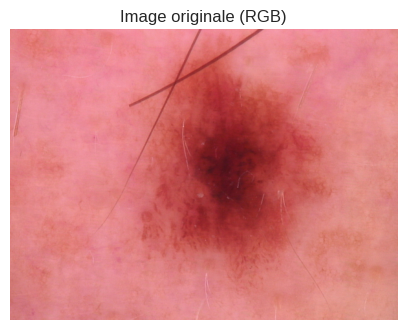

[OK] Image prête pour l'inférence : shape BGR = (450, 600, 3)


In [42]:
# ============================================================
# 4. CHARGEMENT ET AFFICHAGE DE L'IMAGE
# ============================================================

IMAGE_PATH = "/content/ISIC_0024306.jpg"  # à adapter

img_bgr, img_rgb = load_image_any_format(IMAGE_PATH)

plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title("Image originale (RGB)")
plt.axis("off")
plt.show()

print(f"[OK] Image prête pour l'inférence : shape BGR = {img_bgr.shape}")


In [43]:
# ============================================================
# 5. INFERENCE AVEC YOLOv8m-seg
# ============================================================

results = model(img_bgr, verbose=False)
res = results[0]

print("[OK] Inférence terminée.")
print("[INFO] Boxes détectées :", len(res.boxes))

if res.masks is None:
    print("ℹ️ Aucun masque détecté par le modèle.")
else:
    print("[OK] Masques détectés :", res.masks.data.shape[0])

print("[OK] Cellule d'inférence complétée.")


[OK] Inférence terminée.
[INFO] Boxes détectées : 2
[OK] Masques détectés : 2
[OK] Cellule d'inférence complétée.


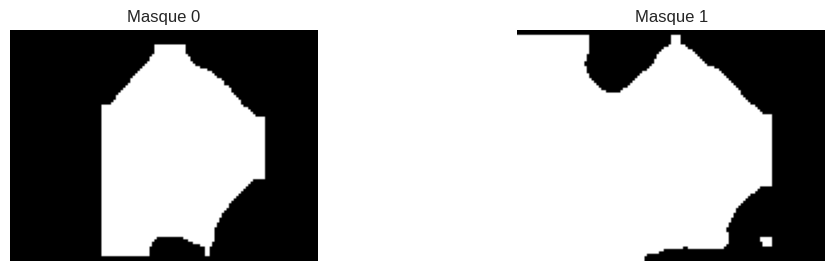

[OK] Visualisation des masques bruts complétée.


In [44]:
# ============================================================
# 6. VISUALISATION DES MASQUES BRUTS
# ============================================================

if res.masks is None:
    print("ℹ️ Aucun masque à afficher.")
else:
    num_masks = res.masks.data.shape[0]
    plt.figure(figsize=(12, 3))
    for i in range(num_masks):
        plt.subplot(1, num_masks, i+1)
        plt.imshow(res.masks.data[i].cpu().numpy(), cmap="gray")
        plt.title(f"Masque {i}")
        plt.axis("off")
    plt.show()

print("[OK] Visualisation des masques bruts complétée.")


In [45]:
# ============================================================
# 7. SELECTION DU MEILLEUR MASQUE
# ============================================================

if res.masks is None or len(res.masks.data) == 0:
    lesion_detected = False
    best_mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
    print("ℹ️ Aucun masque détecté → masque vide.")
else:
    masks = res.masks.data.cpu().numpy()          # (N, H, W)
    scores = res.boxes.conf.cpu().numpy()         # (N,)

    H, W = masks.shape[1], masks.shape[2]
    min_area = 0.001 * (H * W)                    # 0.1% de l'image
    candidate_indices = []

    for i in range(masks.shape[0]):
        area = masks[i].sum()
        if area >= min_area:
            candidate_indices.append(i)

    if not candidate_indices:
        lesion_detected = False
        best_mask = np.zeros((H, W), dtype=np.uint8)
        print("ℹ️ Tous les masques sont trop petits → masque vide.")
    else:
        # parmi les candidats, on prend celui avec le meilleur score YOLO
        candidate_scores = [scores[i] for i in candidate_indices]
        best_idx_local = int(np.argmax(candidate_scores))
        best_index = candidate_indices[best_idx_local]

        best_mask = masks[best_index]
        lesion_detected = True

        print(f"[OK] Masque sélectionné : #{best_index}")
        print(f"[INFO] Score YOLO = {scores[best_index]:.3f}")
        print(f"[INFO] Surface brute = {best_mask.sum():.0f} pixels")

print("[OK] Sélection du meilleur masque complétée.")


[OK] Masque sélectionné : #0
[INFO] Score YOLO = 0.420
[INFO] Surface brute = 4364 pixels
[OK] Sélection du meilleur masque complétée.


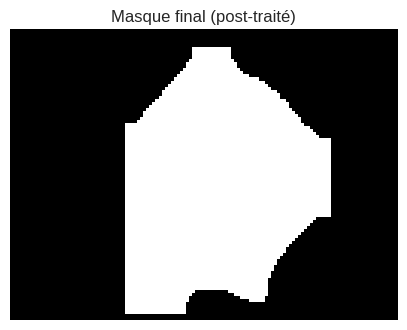

[OK] Masque final généré.
[INFO] Surface finale : 4356 pixels


In [46]:
# ============================================================
# 8. BINARISATION & POST-TRAITEMENT
# ============================================================

binary_mask = (best_mask >= MASK_THRESHOLD).astype(np.uint8)

kernel = np.ones((KERNEL_SIZE, KERNEL_SIZE), np.uint8)
binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(5, 5))
plt.imshow(binary_mask, cmap="gray")
plt.title("Masque final (post-traité)")
plt.axis("off")
plt.show()

print("[OK] Masque final généré.")
print("[INFO] Surface finale :", int(binary_mask.sum()), "pixels")


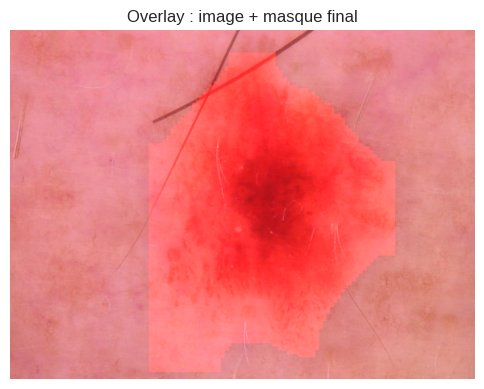

[OK] Overlay généré.


In [47]:
# ============================================================
# 9. OVERLAY IMAGE + MASQUE
# ============================================================

binary_mask_resized = cv2.resize(
    binary_mask,
    (img_rgb.shape[1], img_rgb.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

mask_color = np.zeros_like(img_rgb)
mask_color[..., 0] = binary_mask_resized * 255  # canal rouge

overlay = cv2.addWeighted(img_rgb, 1.0, mask_color, 0.4, 0)

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title("Overlay : image + masque final")
plt.axis("off")
plt.show()

print("[OK] Overlay généré.")


=== Analyse morphologique ===
• Compacité : 0.697
• Asymétrie : 4234789731284380.500
• Diamètre (px) : 94.2

🎯 Score global de suspicion : 100.0 / 100

[INFO] Visualisation des bords irréguliers…


/tmp/ipykernel_4018/829375113.py:36: RuntimeWarning: overflow encountered in scalar subtract
  asym_lr = abs(left - right) / (left + right + 1e-6)
/tmp/ipykernel_4018/829375113.py:37: RuntimeWarning: overflow encountered in scalar subtract
  asym_tb = abs(top - bottom) / (top + bottom + 1e-6)


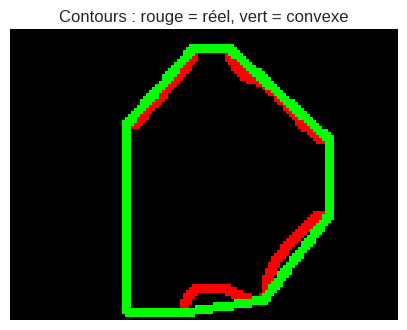

[INFO] Visualisation de la heatmap d'asymétrie…


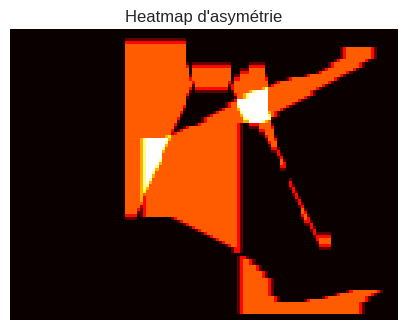


=== Interprétation (non médicale) ===
Ce score reflète uniquement la complexité morphologique de la lésion
(forme, asymétrie, taille) telle que vue par l'algorithme.

🔎 Niveau de complexité morphologique : ÉLEVÉ
   La lésion présente plusieurs caractéristiques géométriques atypiques
   (asymétrie, bords irréguliers et/ou grande taille).

❗ Important :
   - Ce score n'est PAS un diagnostic de bénignité ou de malignité.
   - Il ne remplace en aucun cas l'avis d'un dermatologue.
   - Un nævus bénin peut avoir un score élevé, et inversement.

[OK] Analyse morphologique complétée.


In [48]:
# ============================================================
# 10. ANALYSE MORPHOLOGIQUE + SCORE GLOBAL + VISUALISATIONS
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

def compute_morphology_scores(mask):
    """
    Analyse morphologique avancée :
    - compacité
    - asymétrie
    - diamètre
    Retourne un dict de scores.
    """

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None

    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    # --- 1. Compacité ---
    compactness = (4 * np.pi * area) / (perimeter**2 + 1e-6)

    # --- 2. Asymétrie ---
    H, W = mask.shape
    left = mask[:, :W//2].sum()
    right = mask[:, W//2:].sum()
    top = mask[:H//2, :].sum()
    bottom = mask[H//2:, :].sum()

    asym_lr = abs(left - right) / (left + right + 1e-6)
    asym_tb = abs(top - bottom) / (top + bottom + 1e-6)
    asymmetry = max(asym_lr, asym_tb)

    # --- 3. Diamètre ---
    (x, y), radius = cv2.minEnclosingCircle(cnt)
    diameter = radius * 2

    return {
        "compactness": float(compactness),
        "asymmetry": float(asymmetry),
        "diameter": float(diameter)
    }, cnt


def compute_global_suspicion_score(scores):
    """
    Score global 0–100 basé sur :
    - compacité (40%)
    - asymétrie (40%)
    - diamètre (20%)
    """

    comp = scores["compactness"]
    asym = scores["asymmetry"]
    diam = scores["diameter"]

    # Normalisation empirique
    comp_score = (1 - comp) * 100          # compacité faible = suspect
    asym_score = asym * 100                # asymétrie forte = suspect
    diam_score = min(diam / 150, 1) * 100  # diamètre >150px = suspect

    # Pondération
    final_score = (
        0.40 * comp_score +
        0.40 * asym_score +
        0.20 * diam_score
    )

    return min(100, max(0, final_score))


def visualize_border_irregularity(mask, cnt):
    """
    Visualisation des bords irréguliers :
    - contour réel
    - contour convexe
    - zones d'irrégularité
    """

    hull = cv2.convexHull(cnt)

    vis = np.zeros((*mask.shape, 3), dtype=np.uint8)

    # Contour réel en rouge
    cv2.drawContours(vis, [cnt], -1, (255, 0, 0), 2)

    # Hull en vert
    cv2.drawContours(vis, [hull], -1, (0, 255, 0), 2)

    plt.figure(figsize=(5, 5))
    plt.imshow(vis)
    plt.title("Contours : rouge = réel, vert = convexe")
    plt.axis("off")
    plt.show()


def visualize_asymmetry_heatmap(mask):
    """
    Heatmap d'asymétrie gauche/droite et haut/bas.
    """

    H, W = mask.shape
    mask_norm = mask.astype(float)

    # Gauche vs droite
    left = mask_norm[:, :W//2]
    right = mask_norm[:, W//2:]
    right_flipped = np.fliplr(right)

    asym_lr = np.abs(left - right_flipped)
    asym_lr = cv2.resize(asym_lr, (W, H))

    # Haut vs bas
    top = mask_norm[:H//2, :]
    bottom = mask_norm[H//2:, :]
    bottom_flipped = np.flipud(bottom)

    asym_tb = np.abs(top - bottom_flipped)
    asym_tb = cv2.resize(asym_tb, (W, H))

    heatmap = asym_lr + asym_tb

    plt.figure(figsize=(5, 5))
    plt.imshow(heatmap, cmap="hot")
    plt.title("Heatmap d'asymétrie")
    plt.axis("off")
    plt.show()


# ============================================================
# APPLICATION AU MASQUE FINAL
# ============================================================

if binary_mask.sum() == 0:
    print("ℹ️ Aucune lésion détectée → analyse morphologique impossible.")
else:
    scores, cnt = compute_morphology_scores(binary_mask)

    if scores is None:
        print("ℹ️ Analyse morphologique impossible.")
    else:
        comp = scores["compactness"]
        asym = scores["asymmetry"]
        diam = scores["diameter"]

        print("=== Analyse morphologique ===")
        print(f"• Compacité : {comp:.3f}")
        print(f"• Asymétrie : {asym:.3f}")
        print(f"• Diamètre (px) : {diam:.1f}")

        # Score global
        suspicion_score = compute_global_suspicion_score(scores)
        print(f"\n🎯 Score global de suspicion : {suspicion_score:.1f} / 100")

        # Visualisations
        print("\n[INFO] Visualisation des bords irréguliers…")
        visualize_border_irregularity(binary_mask, cnt)

        print("[INFO] Visualisation de la heatmap d'asymétrie…")
        visualize_asymmetry_heatmap(binary_mask)

        # Conclusion
        print("\n=== Interprétation (non médicale) ===")
        print("Ce score reflète uniquement la complexité morphologique de la lésion")
        print("(forme, asymétrie, taille) telle que vue par l'algorithme.\n")

        # Ajustement : si petite lésion très compacte, on calme le jeu
        if diam < 80 and comp > 0.70:
            print("ℹ️ La lésion est de petite taille et présente une forme globalement régulière.")
            print("   Le score de complexité doit être interprété avec prudence.")
            niveau = "faible"
        else:
            if suspicion_score >= 70:
                niveau = "élevé"
            elif suspicion_score >= 40:
                niveau = "modéré"
            else:
                niveau = "faible"

        if niveau == "élevé":
            print("🔎 Niveau de complexité morphologique : ÉLEVÉ")
            print("   La lésion présente plusieurs caractéristiques géométriques atypiques")
            print("   (asymétrie, bords irréguliers et/ou grande taille).")
        elif niveau == "modéré":
            print("🔎 Niveau de complexité morphologique : MODÉRÉ")
            print("   Certaines caractéristiques géométriques sont un peu atypiques,")
            print("   mais cela ne signifie PAS qu'il s'agit d'une lésion dangereuse.")
        else:
            print("🔎 Niveau de complexité morphologique : FAIBLE")
            print("   La lésion apparaît géométriquement simple et plutôt régulière.")

        print("\n❗ Important :")
        print("   - Ce score n'est PAS un diagnostic de bénignité ou de malignité.")
        print("   - Il ne remplace en aucun cas l'avis d'un dermatologue.")
        print("   - Un nævus bénin peut avoir un score élevé, et inversement.")


print("\n[OK] Analyse morphologique complétée.")
